Name:Disha Dipak Naik
Roll No:CS35

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


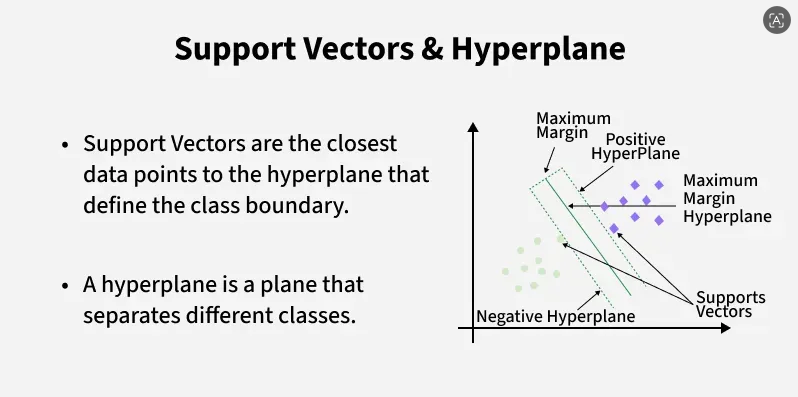
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Iris dataset
df_iris = pd.read_csv('/content/Iris.csv')

# Display the first 5 rows of the dataset
print("First 5 rows of the Iris dataset:")
display(df_iris.head())

# Display information about the dataset
print("\nInformation about the Iris dataset:")
display(df_iris.info())

First 5 rows of the Iris dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Information about the Iris dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


None

# Task 2: Explore the Dataset

In [2]:
# Display descriptive statistics of the dataset
print("Descriptive statistics of the Iris dataset:")
display(df_iris.describe())

Descriptive statistics of the Iris dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [3]:
# Check for missing values
print("\nMissing values in each column:")
display(df_iris.isnull().sum())


Missing values in each column:


,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


### Visualize Feature Distributions

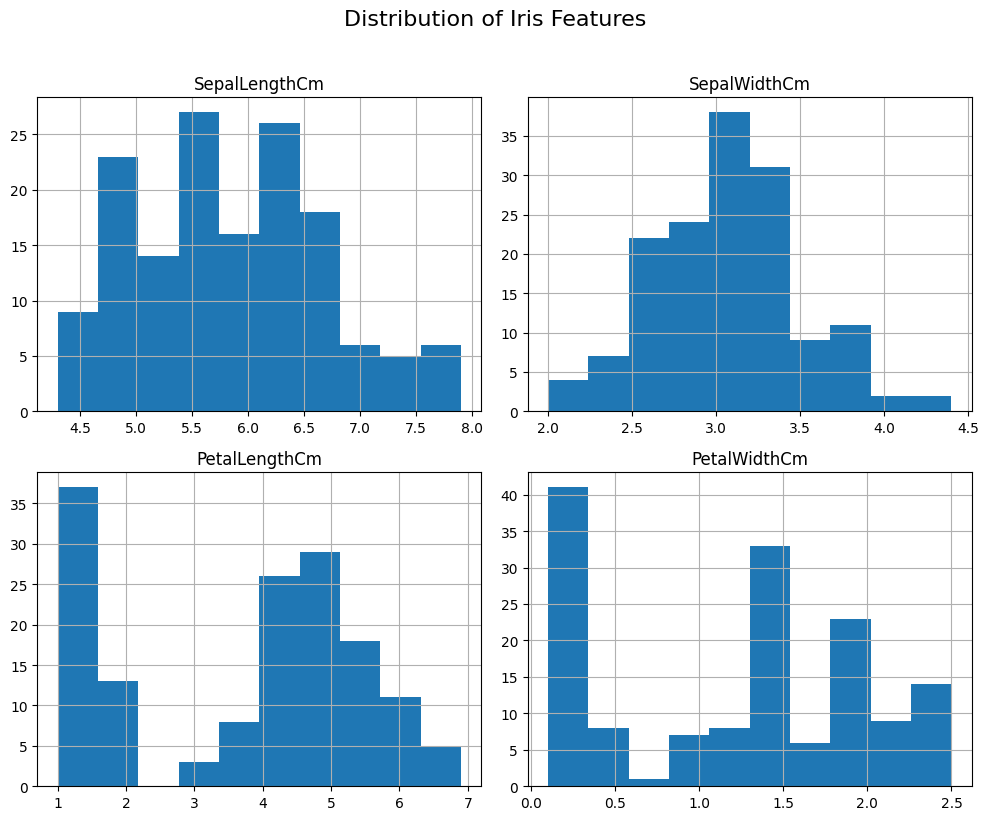

In [4]:
# Drop 'Id' column before plotting for cleaner visualizations if it's not needed for analysis
df_plot = df_iris.drop(columns=['Id'])

# Plot histograms for numerical features
df_plot.hist(figsize=(10, 8))
plt.suptitle('Distribution of Iris Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Visualize Relationships Between Features

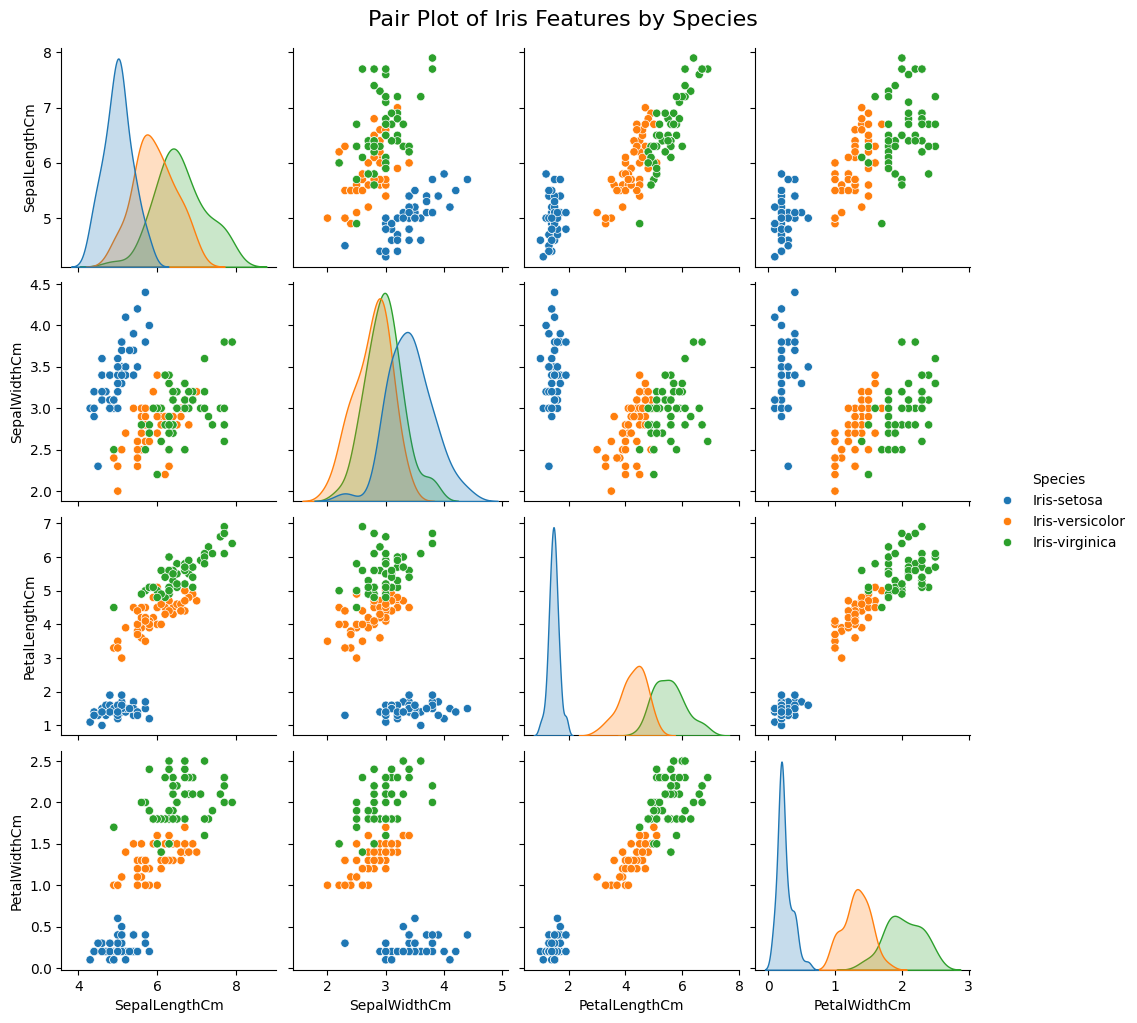

In [5]:
# Pairplot to visualize relationships between all features, colored by Species
sns.pairplot(df_plot, hue='Species', markers='o')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02, fontsize=16)
plt.show()

In [6]:
# Drop the 'Id' column as it is not needed for the model
df_iris_processed = df_iris.drop('Id', axis=1)

# Define features (X) and target (y)
X = df_iris_processed.drop('Species', axis=1)
y = df_iris_processed['Species']

# Encode the target variable (Species) into numerical format
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y_encoded.shape)
print("\nFirst 5 rows of features (X):")
display(X.head())
print("\nFirst 5 values of encoded target (y):")
display(y_encoded[:5])
print("\nOriginal Species labels:", le.classes_)

Features (X) shape: (150, 4)
Target (y) shape: (150,)

First 5 rows of features (X):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



First 5 values of encoded target (y):


array([0, 0, 0, 0, 0])


Original Species labels: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [8]:
# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 rows of scaled X_train:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())
print("\nFirst 5 rows of scaled X_test:")
display(pd.DataFrame(X_test_scaled, columns=X.columns).head())

First 5 rows of scaled X_train:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-1.473937,1.220379,-1.563987,-1.309484
1,-0.133071,3.020017,-1.277280,-1.042922
2,1.085898,0.095606,0.385621,0.289886
3,-1.230143,0.770470,-1.219939,-1.309484
4,-1.717731,0.320560,-1.391963,-1.309484



First 5 rows of scaled X_test:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.354517,-0.579258,0.557645,0.023324
1,-0.133071,1.670289,-1.162597,-1.176203
2,2.304867,-1.029168,1.819157,1.489413
3,0.232620,-0.354304,0.442962,0.423166
4,1.207795,-0.579258,0.614987,0.289886


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [9]:
# Initialize a Linear SVM classifier
svm_linear = SVC(kernel='linear', random_state=42)

# Train the model on the scaled training data
svm_linear.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_linear_svm = svm_linear.predict(X_test_scaled)

print("Linear SVM model trained successfully.")
print("First 5 predictions of Linear SVM:", y_pred_linear_svm[:5])

Linear SVM model trained successfully.
First 5 predictions of Linear SVM: [1 0 2 1 1]


In [10]:
# Calculate the accuracy of the Linear SVM model
accuracy_linear_svm = accuracy_score(y_test, y_pred_linear_svm)
print(f"Linear SVM Accuracy: {accuracy_linear_svm:.4f}")

# Generate the confusion matrix
conf_matrix_linear_svm = confusion_matrix(y_test, y_pred_linear_svm)
print("\nLinear SVM Confusion Matrix:")
display(pd.DataFrame(conf_matrix_linear_svm, index=['Actual 0', 'Actual 1', 'Actual 2'], columns=['Predicted 0', 'Predicted 1', 'Predicted 2']))

# Generate the classification report
class_report_linear_svm = classification_report(y_test, y_pred_linear_svm, target_names=le.classes_)
print("\nLinear SVM Classification Report:")
print(class_report_linear_svm)

Linear SVM Accuracy: 0.9667

Linear SVM Confusion Matrix:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,10,0,0
Actual 1,0,8,1
Actual 2,0,0,11



Linear SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [11]:
# Select only Petal Length and Petal Width for 2D visualization
X_2d = df_iris_processed[['PetalLengthCm', 'PetalWidthCm']]
y_2d = y_encoded

# Split the 2D data into training and testing sets
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

print("X_2d_train shape:", X_2d_train.shape)
print("X_2d_test shape:", X_2d_test.shape)

X_2d_train shape: (120, 2)
X_2d_test shape: (30, 2)


In [12]:
# Scale the 2D features
scaler_2d = StandardScaler()
X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)
X_2d_test_scaled = scaler_2d.transform(X_2d_test)

print("First 5 rows of scaled 2D X_train:")
display(pd.DataFrame(X_2d_train_scaled, columns=X_2d.columns).head())

First 5 rows of scaled 2D X_train:


,PetalLengthCm,PetalWidthCm
0,-1.563987,-1.309484
1,-1.277280,-1.042922
2,0.385621,0.289886
3,-1.219939,-1.309484
4,-1.391963,-1.309484


In [13]:
# Train a Linear SVM model on the scaled 2D training data
svm_linear_2d = SVC(kernel='linear', random_state=42)
svm_linear_2d.fit(X_2d_train_scaled, y_2d_train)

print("Linear SVM model (2D) trained successfully.")

Linear SVM model (2D) trained successfully.


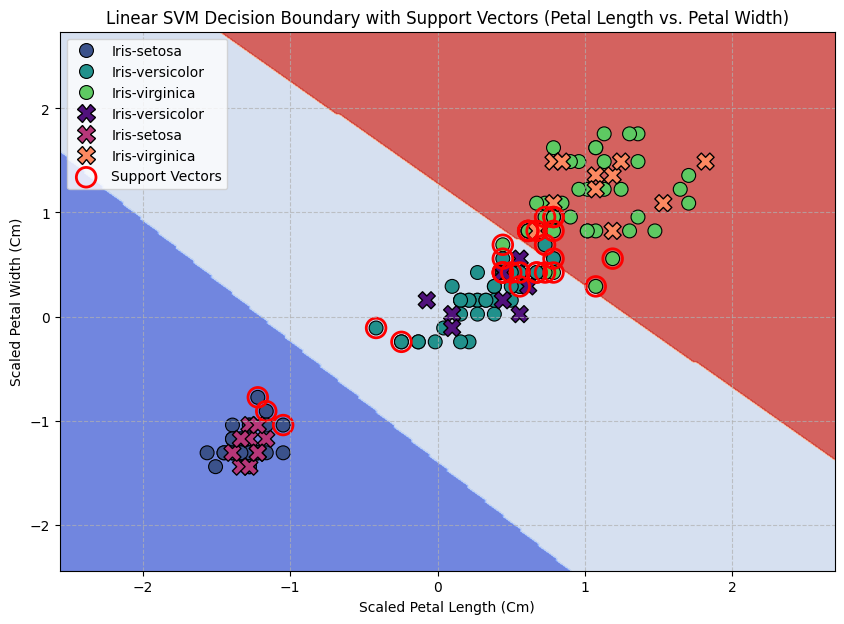

In [15]:
# Plot the decision boundary
plt.figure(figsize=(10, 7))

x_min, x_max = X_2d_train_scaled[:, 0].min() - 1, X_2d_train_scaled[:, 0].max() + 1
y_min, y_max = X_2d_train_scaled[:, 1].min() - 1, X_2d_train_scaled[:, 1].max() + 1
h = 0.02 # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = svm_linear_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot also the training points
sns.scatterplot(x=X_2d_train_scaled[:, 0], y=X_2d_train_scaled[:, 1], hue=le.inverse_transform(y_2d_train),
                palette='viridis', marker='o', s=100, edgecolor='k')

# Plot the test points
sns.scatterplot(x=X_2d_test_scaled[:, 0], y=X_2d_test_scaled[:, 1], hue=le.inverse_transform(y_2d_test),
                palette='magma', marker='X', s=150, edgecolor='k')

# Plot support vectors
plt.scatter(svm_linear_2d.support_vectors_[:, 0], svm_linear_2d.support_vectors_[:, 1], s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')

plt.xlabel('Scaled Petal Length (Cm)')
plt.ylabel('Scaled Petal Width (Cm)')
plt.title('Linear SVM Decision Boundary with Support Vectors (Petal Length vs. Petal Width)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

### Train Logistic Regression Model

Train a Logistic Regression model using the same two features (Petal Length and Petal Width) and the scaled 2D training data.

In [16]:
# Initialize a Logistic Regression classifier
log_reg = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto')

# Train the model on the scaled 2D training data
log_reg.fit(X_2d_train_scaled, y_2d_train)

print("Logistic Regression model (2D) trained successfully.")

Logistic Regression model (2D) trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Plot Logistic Regression Decision Boundary

Visualize the decision boundary of the Logistic Regression model along with the data points.

### Plot Both Decision Boundaries

Plot the decision boundaries of both the Linear SVM and Logistic Regression models on the same graph.

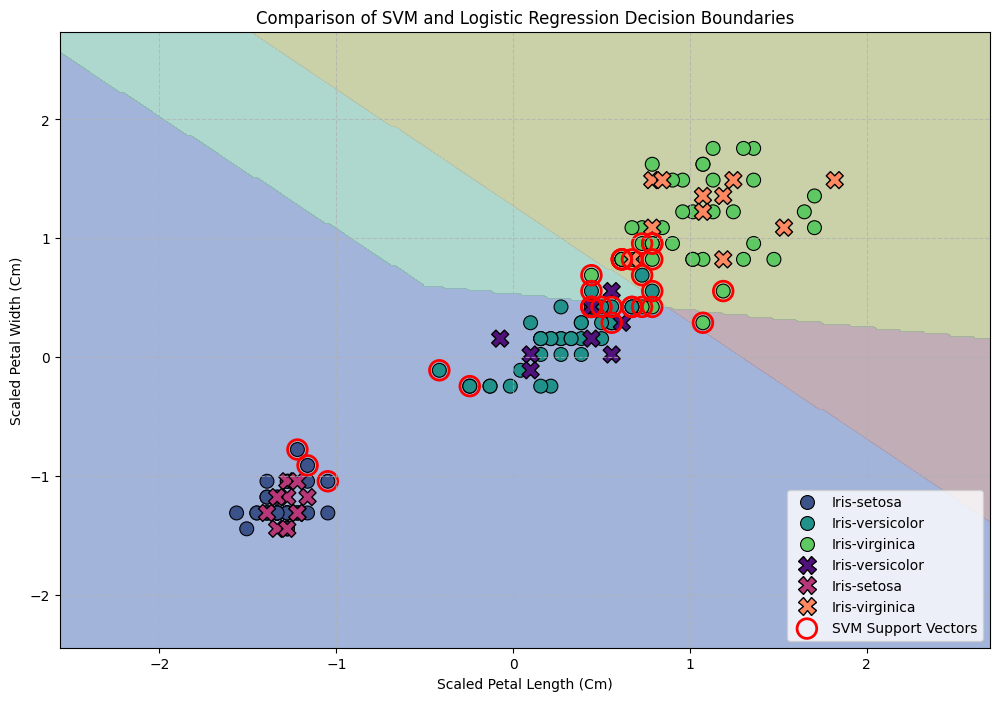

In [19]:
# Plot the decision boundaries for both models
plt.figure(figsize=(12, 8))

# SVM Decision Boundary
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.4, levels=np.arange(Z.min(), Z.max() + 1)) # Explicit levels to ensure clear boundaries

# Logistic Regression Decision Boundary
plt.contourf(xx, yy, Z_log_reg, cmap=plt.cm.viridis, alpha=0.3, levels=np.arange(Z_log_reg.min(), Z_log_reg.max() + 1)) # Using different cmap and alpha for distinction

# Plot training points
sns.scatterplot(x=X_2d_train_scaled[:, 0], y=X_2d_train_scaled[:, 1], hue=le.inverse_transform(y_2d_train),
                palette='viridis', marker='o', s=100, edgecolor='k')

# Plot test points
sns.scatterplot(x=X_2d_test_scaled[:, 0], y=X_2d_test_scaled[:, 1], hue=le.inverse_transform(y_2d_test),
                palette='magma', marker='X', s=150, edgecolor='k')

# Plot SVM support vectors
plt.scatter(svm_linear_2d.support_vectors_[:, 0], svm_linear_2d.support_vectors_[:, 1], s=200, facecolors='none', edgecolors='red', linewidth=2, label='SVM Support Vectors')

plt.xlabel('Scaled Petal Length (Cm)')
plt.ylabel('Scaled Petal Width (Cm)')
plt.title('Comparison of SVM and Logistic Regression Decision Boundaries')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

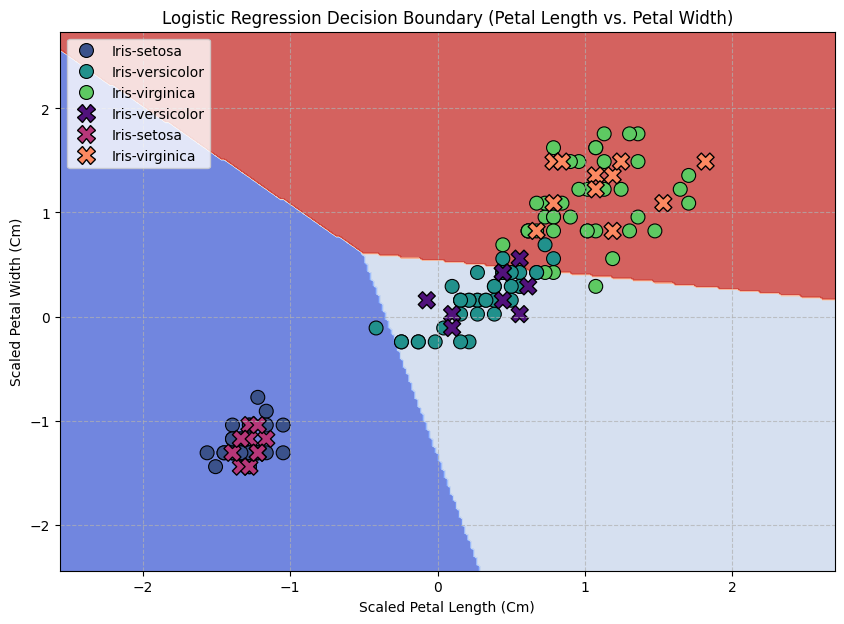

In [17]:
# Plot the decision boundary for Logistic Regression
plt.figure(figsize=(10, 7))

# Reuse the meshgrid from SVM visualization
Z_log_reg = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z_log_reg = Z_log_reg.reshape(xx.shape)
plt.contourf(xx, yy, Z_log_reg, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot also the training points
sns.scatterplot(x=X_2d_train_scaled[:, 0], y=X_2d_train_scaled[:, 1], hue=le.inverse_transform(y_2d_train),
                palette='viridis', marker='o', s=100, edgecolor='k')

# Plot the test points
sns.scatterplot(x=X_2d_test_scaled[:, 0], y=X_2d_test_scaled[:, 1], hue=le.inverse_transform(y_2d_test),
                palette='magma', marker='X', s=150, edgecolor='k')

plt.xlabel('Scaled Petal Length (Cm)')
plt.ylabel('Scaled Petal Width (Cm)')
plt.title('Logistic Regression Decision Boundary (Petal Length vs. Petal Width)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [39]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Fallback to locate the trained SVM model variable dynamically
if 'svm_model' in globals():
    model = svm_model
elif 'svm_linear' in globals():
    model = svm_linear
elif 'svm' in globals():
    model = svm
elif 'model' in globals():
    model = model
else:
    raise NameError("No SVM model found. Please ensure your trained model variable (e.g., svm_model, svm_linear, or svm) is defined.")

# 2. Check and select the test features dataset
if 'X_test_scaled' in globals():
    X_test_data = X_test_scaled
elif 'X_test' in globals():
    X_test_data = X_test
else:
    raise NameError("Neither 'X_test_scaled' nor 'X_test' could be found.")

# 3. Generate Predictions safely
y_pred_svm = model.predict(X_test_data)

# 4. Calculate Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.4f}\n")

# 5. Confusion Matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# Safely extract class names for dataframe labels
if 'le' in globals() and hasattr(le, 'classes_'):
    target_labels = [str(c) for c in le.classes_]
else:
    target_labels = [str(c) for c in np.unique(y_test)]

conf_matrix_df = pd.DataFrame(
    conf_matrix_svm,
    index=[f"Actual {cls}" for cls in target_labels],
    columns=[f"Predicted {cls}" for cls in target_labels]
)

print("Confusion Matrix:")
print(conf_matrix_df)
print("\n" + "=" * 55 + "\n")

# 6. Classification Report (Precision, Recall, F1-Score, Support)
class_report_svm = classification_report(
    y_test,
    y_pred_svm,
    target_names=target_labels
)

print("Classification Report:")
print(class_report_svm)

SVM Model Accuracy: 0.9667

Confusion Matrix:
                        Predicted Iris-setosa  Predicted Iris-versicolor  \
Actual Iris-setosa                         10                          0   
Actual Iris-versicolor                      0                          8   
Actual Iris-virginica                       0                          0   

                        Predicted Iris-virginica  
Actual Iris-setosa                             0  
Actual Iris-versicolor                         1  
Actual Iris-virginica                         11  


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

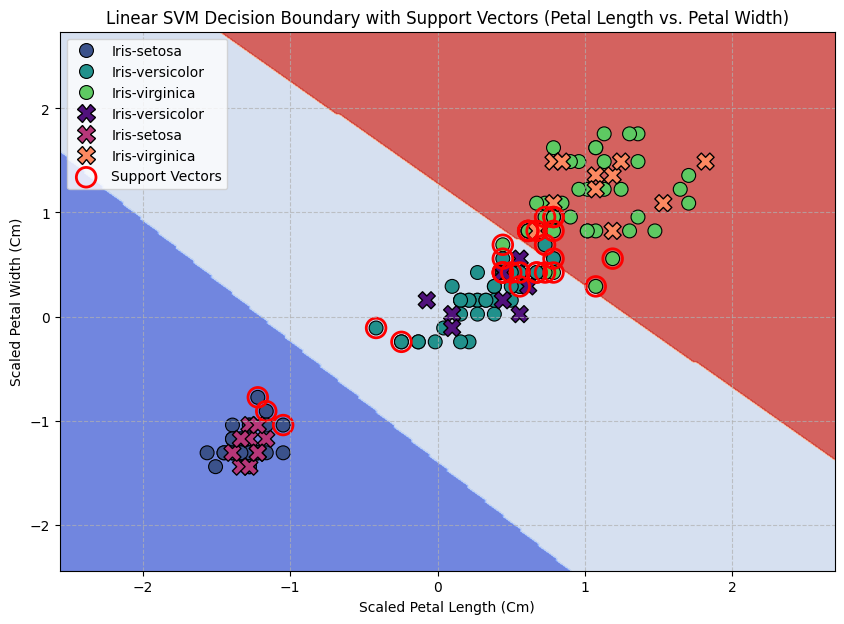

In [22]:
# Plot the decision boundary
plt.figure(figsize=(10, 7))

x_min, x_max = X_2d_train_scaled[:, 0].min() - 1, X_2d_train_scaled[:, 0].max() + 1
y_min, y_max = X_2d_train_scaled[:, 1].min() - 1, X_2d_train_scaled[:, 1].max() + 1
h = 0.02 # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = svm_linear_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot also the training points
sns.scatterplot(x=X_2d_train_scaled[:, 0], y=X_2d_train_scaled[:, 1], hue=le.inverse_transform(y_2d_train),
                palette='viridis', marker='o', s=100, edgecolor='k')

# Plot the test points
sns.scatterplot(x=X_2d_test_scaled[:, 0], y=X_2d_test_scaled[:, 1], hue=le.inverse_transform(y_2d_test),
                palette='magma', marker='X', s=150, edgecolor='k')

# Plot support vectors
plt.scatter(svm_linear_2d.support_vectors_[:, 0], svm_linear_2d.support_vectors_[:, 1], s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')

plt.xlabel('Scaled Petal Length (Cm)')
plt.ylabel('Scaled Petal Width (Cm)')
plt.title('Linear SVM Decision Boundary with Support Vectors (Petal Length vs. Petal Width)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

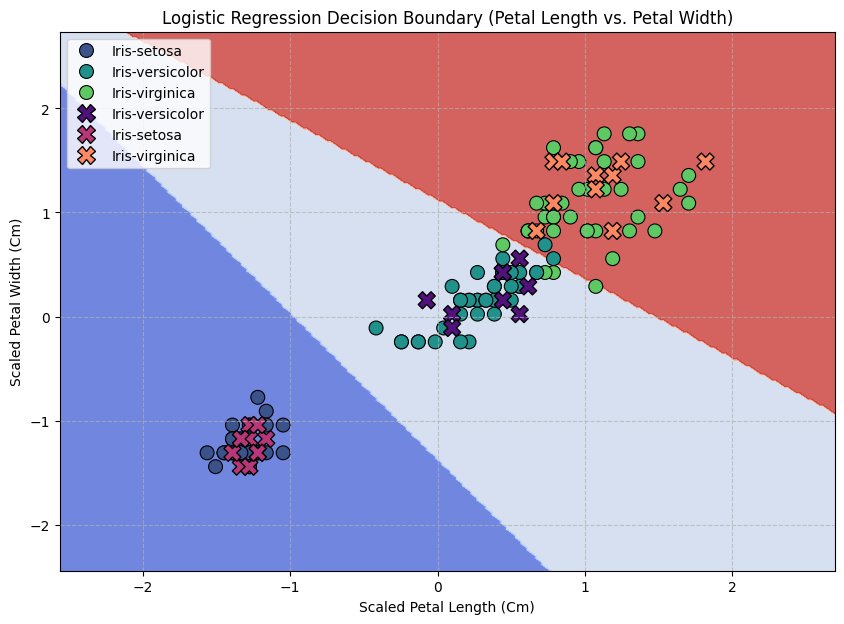

In [34]:
# 1. Initialize and train Logistic Regression model on the 2D scaled data
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_2d_train_scaled, y_2d_train)

# 2. Define the meshgrid range for plotting
x_min, x_max = X_2d_train_scaled[:, 0].min() - 1, X_2d_train_scaled[:, 0].max() + 1
y_min, y_max = X_2d_train_scaled[:, 1].min() - 1, X_2d_train_scaled[:, 1].max() + 1
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 3. Predict class labels over the meshgrid grid
Z_log_reg = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z_log_reg = Z_log_reg.reshape(xx.shape)

# 4. Plot the decision boundary and sample points
plt.figure(figsize=(10, 7))

# Contour plot for decision regions
plt.contourf(xx, yy, Z_log_reg, cmap=plt.cm.coolwarm, alpha=0.8)

# Training data points
sns.scatterplot(
    x=X_2d_train_scaled[:, 0],
    y=X_2d_train_scaled[:, 1],
    hue=le.inverse_transform(y_2d_train),
    palette='viridis',
    marker='o',
    s=100,
    edgecolor='k'
)

# Test data points
sns.scatterplot(
    x=X_2d_test_scaled[:, 0],
    y=X_2d_test_scaled[:, 1],
    hue=le.inverse_transform(y_2d_test),
    palette='magma',
    marker='X',
    s=150,
    edgecolor='k'
)

plt.xlabel('Scaled Petal Length (Cm)')
plt.ylabel('Scaled Petal Width (Cm)')
plt.title('Logistic Regression Decision Boundary (Petal Length vs. Petal Width)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

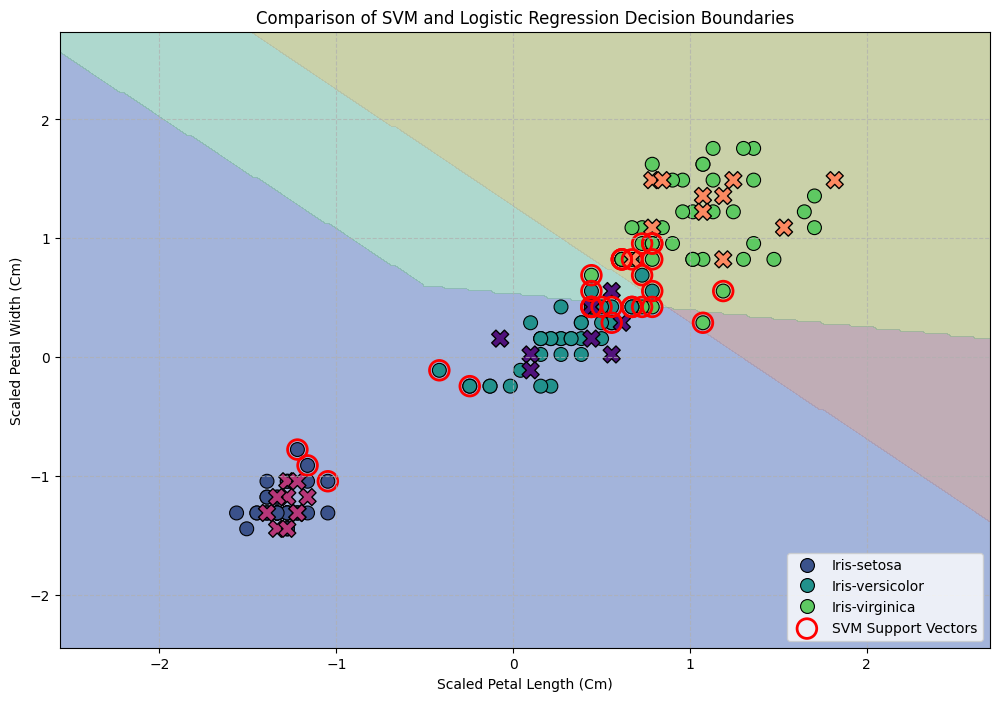

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the decision boundaries for both models
plt.figure(figsize=(12, 8))

# SVM Decision Boundary
# Z was computed in cell 6055b57e using svm_linear_2d
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.4, levels=np.arange(Z.min(), Z.max() + 1)) # Explicit levels to ensure clear boundaries

# Logistic Regression Decision Boundary
# Z_log_reg was computed in cell de475266 using log_reg
plt.contourf(xx, yy, Z_log_reg, cmap=plt.cm.viridis, alpha=0.3, levels=np.arange(Z_log_reg.min(), Z_log_reg.max() + 1)) # Using different cmap and alpha for distinction

# Plot training points
sns.scatterplot(x=X_2d_train_scaled[:, 0], y=X_2d_train_scaled[:, 1], hue=le.inverse_transform(y_2d_train),
                palette='viridis', marker='o', s=100, edgecolor='k', legend='full') # Removed label='Training Data'

# Plot test points
sns.scatterplot(x=X_2d_test_scaled[:, 0], y=X_2d_test_scaled[:, 1], hue=le.inverse_transform(y_2d_test),
                palette='magma', marker='X', s=150, edgecolor='k', legend=False) # Removed label='Test Data'

# Plot SVM support vectors
plt.scatter(svm_linear_2d.support_vectors_[:, 0], svm_linear_2d.support_vectors_[:, 1], s=200, facecolors='none', edgecolors='red', linewidth=2, label='SVM Support Vectors')

plt.xlabel('Scaled Petal Length (Cm)')
plt.ylabel('Scaled Petal Width (Cm)')
plt.title('Comparison of SVM and Logistic Regression Decision Boundaries')

# Custom legend for regions and data points
# Note: contourf does not automatically add entries to the legend.
# The seaborn scatterplot creates its own legend for the 'hue' variable, which is handled by 'legend='full''.
# We'll rely on seaborn's legend for the species and explicitly add SVM Support Vectors.
plt.legend(loc='lower right') # This will combine the scatterplot legend and custom labels

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

Accuracy Comparison (2D Models)
---------------------------------
Linear SVM (2D):        1.0000
Logistic Regression (2D): 0.9667

Linear SVM (2D) Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Logistic Regression (2D) Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


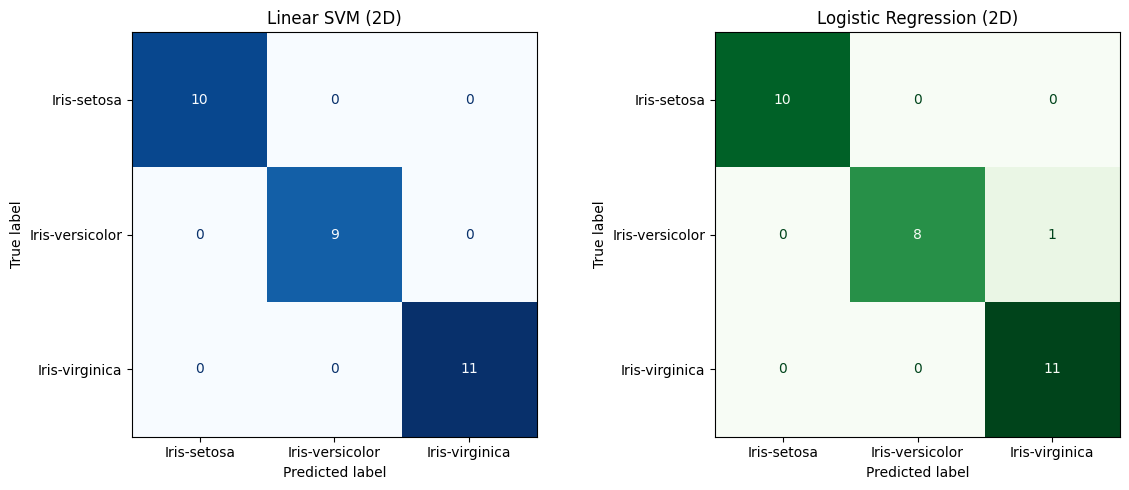


Linear SVM (2D) Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Logistic Regression (2D) Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [30]:
# Task 10: Compare Performance

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Make predictions on the 2D scaled test set using the 2D models
svm_pred_2d = svm_linear_2d.predict(X_2d_test_scaled)
lr_pred_2d = log_reg.predict(X_2d_test_scaled)

# --------------------------------------------------
# 1. Accuracy
# --------------------------------------------------

svm_accuracy_2d = accuracy_score(y_2d_test, svm_pred_2d)
lr_accuracy_2d = accuracy_score(y_2d_test, lr_pred_2d)

print("Accuracy Comparison (2D Models)")
print("---------------------------------")
print(f"Linear SVM (2D):        {svm_accuracy_2d:.4f}")
print(f"Logistic Regression (2D): {lr_accuracy_2d:.4f}")


# --------------------------------------------------
# 2. Confusion Matrices
# --------------------------------------------------

svm_cm_2d = confusion_matrix(y_2d_test, svm_pred_2d)
lr_cm_2d = confusion_matrix(y_2d_test, lr_pred_2d)

print("\nLinear SVM (2D) Confusion Matrix:")
print(svm_cm_2d)

print("\nLogistic Regression (2D) Confusion Matrix:")
print(lr_cm_2d)


# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=svm_cm_2d,
    display_labels=le.classes_
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Linear SVM (2D)")

ConfusionMatrixDisplay(
    confusion_matrix=lr_cm_2d,
    display_labels=le.classes_
).plot(ax=axes[1], cmap="Greens", colorbar=False)

axes[1].set_title("Logistic Regression (2D)")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Classification Reports
# --------------------------------------------------

print("\nLinear SVM (2D) Classification Report:")
print(classification_report(y_2d_test, svm_pred_2d, target_names=le.classes_))

print("\nLogistic Regression (2D) Classification Report:")
print(classification_report(y_2d_test, lr_pred_2d, target_names=le.classes_))

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.

### Conclusion Summary

Based on the analysis, provide a summary of the findings, including:

1.  **Effectiveness of SVM:** How well did the SVM perform, especially with a linear kernel?
2.  **Comparison with Logistic Regression:** What were the key differences and similarities in the decision boundaries and performance metrics between SVM and Logistic Regression?
3.  **Insights from Visualization:** What did the decision boundary plots reveal about the classification tasks?
4.  **Support Vectors:** Briefly mention the role and significance of support vectors.